# 📊 Data Analysis for AI/ML — Complete Revision Notebook
### Module 3 | Day 1 + Day 2

This notebook consolidates the full **Data Analysis** revision:

- **Day 1** — What is Data Analysis, why it matters for AI/ML, types of data, data collection, data quality & cleaning
- **Day 2** — Exploratory Data Analysis (EDA), Data Visualization, Feature Engineering, Data Preprocessing, Data Splitting, Essential Python Libraries

Each section has a short explanation followed by runnable code, using a small synthetic dataset so every concept can be demonstrated end-to-end.

**Data Preparation Pipeline (the big picture):**

`Raw Data → Data Cleaning → EDA → Feature Engineering → Encoding & Scaling → Train/Validation/Test Split → Machine Learning Model`


## 🐍 0. Essential Python Libraries — Setup

The core libraries used throughout any Data Analysis / ML workflow:

| Library | Purpose |
|---|---|
| **NumPy** | Numerical computing, arrays, math operations |
| **Pandas** | Loading, cleaning, and manipulating tabular data |
| **Matplotlib** | Base plotting library for visualizations |
| **Seaborn** | Statistical visualizations built on Matplotlib |
| **Scikit-learn** | Preprocessing, encoding, scaling, train/test split, ML models |

Let's import everything we'll need.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import (
    MinMaxScaler, StandardScaler, LabelEncoder, OneHotEncoder
)

# Nicer plot defaults
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (7, 4)

print("Libraries loaded successfully ✅")


Libraries loaded successfully ✅


## 🧪 Creating a Sample Dataset

To make every concept concrete, we'll create a small synthetic **"Student Study Habits"** dataset
(similar spirit to the *StudySmart AI* project from Module 1). It intentionally contains:

- Missing values
- A duplicate record
- An outlier
- A mix of qualitative (categorical) and quantitative (numerical) data
- A mix of structured columns you'd find in any real-world dataset

This lets us demonstrate cleaning, EDA, feature engineering, and preprocessing on data that behaves like the real world.


In [2]:
np.random.seed(42)

n = 60

data = {
    "student_id": range(1, n + 1),
    "study_hours": np.round(np.random.normal(4, 1.5, n), 1),
    "sleep_hours": np.round(np.random.normal(7, 1, n), 1),
    "attendance_pct": np.round(np.random.uniform(60, 100, n), 1),
    "study_method": np.random.choice(
        ["Reading", "Practice", "Video", "Group Study"], n
    ),
    "score": np.round(np.random.normal(70, 12, n), 1),
}

df = pd.DataFrame(data)

# Inject missing values (realistic messiness)
df.loc[[3, 15, 40], "study_hours"] = np.nan
df.loc[[7, 22], "sleep_hours"] = np.nan
df.loc[10, "study_method"] = np.nan

# Inject a duplicate row
df = pd.concat([df, df.iloc[[5]]], ignore_index=True)

# Inject an outlier
df.loc[0, "study_hours"] = 40  # unrealistic value

df.head(10)


   student_id  study_hours  sleep_hours  attendance_pct study_method  score
0           1         40.0          6.5            69.5  Group Study   59.8
1           2          3.8          6.8            89.1  Group Study   51.8
2           3          5.0          5.9            74.7        Video   64.6
3           4          NaN          5.8            85.3        Video   80.3
4           5          3.6          7.8            85.3      Reading   72.6
5           6          3.6          8.4            81.4  Group Study   55.1
6           7          6.4          6.9            63.6      Reading   72.1
7           8          5.2          NaN            93.4  Group Study   74.6
8           9          3.3          7.4            72.8  Group Study   59.4
9          10          4.8          6.4            67.5        Video   71.8

---
# 📅 Day 1 — Foundations of Data Analysis


## 1. What is Data Analysis?

**Data Analysis** is the process of inspecting, cleaning, transforming, and interpreting data to
discover useful information, patterns, and insights. It helps answer:

- What does the data tell us?
- Are there hidden patterns?
- Which factors influence outcomes?
- Is the data ready for machine learning?

A model doesn't understand the real world directly — it only learns from the data we give it. That's why
Data Analysis is the true starting point of every AI/ML project.


In [3]:
# A first look at the dataset — structure and basic info
print("Shape (rows, columns):", df.shape)
print()
df.info()


Shape (rows, columns): (61, 6)

<class 'pandas.DataFrame'>
RangeIndex: 61 entries, 0 to 60
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   student_id      61 non-null     int64  
 1   study_hours     58 non-null     float64
 2   sleep_hours     59 non-null     float64
 3   attendance_pct  61 non-null     float64
 4   study_method    60 non-null     str    
 5   score           61 non-null     float64
dtypes: float64(4), int64(1), str(1)
memory usage: 3.0 KB


## 2. Why Data Analysis is Important for AI/ML

Before training any ML model, data analysis helps us:

- Understand the structure and behavior of the dataset
- Detect errors and inconsistencies
- Identify important features
- Improve data quality
- Make better decisions during model development

> A powerful algorithm with poor-quality data can fail, while a well-prepared dataset can significantly
> improve model performance.


In [4]:
# Summary statistics — a quick way to understand the data's behavior
df.describe()


       student_id  study_hours  sleep_hours  attendance_pct       score
count   61.000000    58.000000    59.000000       61.000000   61.000000
mean    30.098361     4.320690     6.986441       79.300000   69.978689
std     17.599910     4.947718     0.942750       11.513051   12.550699
min      1.000000     1.100000     4.400000       60.200000   45.700000
25%     15.000000     2.925000     6.500000       69.100000   61.200000
50%     30.000000     3.600000     7.000000       81.400000   70.800000
75%     45.000000     4.500000     7.400000       87.700000   77.600000
max     60.000000    40.000000     9.500000       97.500000  116.200000

## 3. Types of Data

| Type | Description | Example in our dataset |
|---|---|---|
| **Qualitative (Categorical)** | Descriptive labels/categories | `study_method` |
| **Quantitative (Numerical)** | Numbers used for math/statistics | `study_hours`, `score` |
| **Structured Data** | Organized in rows/columns (tables, databases) | Our entire DataFrame |
| **Unstructured Data** | Text, images, audio, video | Not shown here, but e.g. essays or lecture recordings |


In [5]:
# Separating column types programmatically
numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()

print("Numerical (Quantitative) columns:", numerical_cols)
print("Categorical (Qualitative) columns:", categorical_cols)


Numerical (Quantitative) columns: ['student_id', 'study_hours', 'sleep_hours', 'attendance_pct', 'score']
Categorical (Qualitative) columns: ['study_method']


## 4. Data Collection

Real datasets typically come from sources such as:

- **Databases** (SQL/NoSQL)
- **APIs**
- **Web Scraping**
- **Surveys**
- **Sensors / IoT devices**

The quality and relevance of collected data directly affects the quality of the resulting AI solution.
For this notebook, our dataset was generated synthetically — but the same structure applies whether
data comes from a CSV export, a database query, or an API response.


In [6]:
# Example: this is how you'd typically load real data instead of generating it
# df = pd.read_csv("students.csv")
# df = pd.read_json("students.json")
# df = pd.read_sql("SELECT * FROM students", connection)

print("In practice, use pd.read_csv / pd.read_json / pd.read_sql to load real datasets.")


In practice, use pd.read_csv / pd.read_json / pd.read_sql to load real datasets.


## 5. Data Quality & Data Cleaning

Real-world datasets are rarely perfect. Common issues include:

- Missing values
- Duplicate records
- Incorrect data
- Inconsistent formats
- Outliers

Let's detect each of these in our dataset.


In [7]:
# 5.1 Detecting missing values
print("Missing values per column:")
print(df.isnull().sum())


Missing values per column:
student_id        0
study_hours       3
sleep_hours       2
attendance_pct    0
study_method      1
score             0
dtype: int64


In [8]:
# 5.2 Detecting duplicate records
print("Number of duplicate rows:", df.duplicated().sum())
df[df.duplicated()]


Number of duplicate rows: 1


    student_id  study_hours  sleep_hours  attendance_pct study_method  score
60           6          3.6          8.4            81.4  Group Study   55.1

In [9]:
# 5.3 Detecting outliers using the IQR method (study_hours)
Q1 = df["study_hours"].quantile(0.25)
Q3 = df["study_hours"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df["study_hours"] < lower_bound) | (df["study_hours"] > upper_bound)]
print(f"Valid range: [{lower_bound:.2f}, {upper_bound:.2f}]")
print("Outliers found:")
outliers[["student_id", "study_hours"]]


Valid range: [0.56, 6.86]
Outliers found:


   student_id  study_hours
0           1         40.0

In [10]:
# 5.4 Cleaning: remove duplicates and fix the outlier
df_clean = df.drop_duplicates().copy()

# Cap the unrealistic outlier back to a sensible range instead of deleting the row
df_clean.loc[df_clean["study_hours"] > 15, "study_hours"] = df_clean["study_hours"].median()

print("Shape after cleaning:", df_clean.shape)
df_clean.describe()


Shape after cleaning: (60, 6)


       student_id  study_hours  sleep_hours  attendance_pct       score
count   60.000000    57.000000    58.000000       60.000000   60.000000
mean    30.500000     3.694737     6.962069       79.265000   70.226667
std     17.464249     1.336362     0.932047       11.606936   12.505007
min      1.000000     1.100000     4.400000       60.200000   45.700000
25%     15.750000     2.900000     6.500000       69.075000   61.350000
50%     30.500000     3.600000     7.000000       81.650000   70.900000
75%     45.250000     4.500000     7.400000       87.900000   77.650000
max     60.000000     6.800000     9.500000       97.500000  116.200000

---
# 📅 Day 2 — EDA, Visualization, Feature Engineering & Preprocessing


## 6. Exploratory Data Analysis (EDA)

EDA is about exploring a dataset before model development to understand:

- Dataset structure
- Summary statistics
- Data distributions
- Relationships between variables
- Missing values and outliers

EDA answers the key question: **"What story is the data trying to tell?"**


In [11]:
# Summary statistics for numerical features
df_clean.describe()


       student_id  study_hours  sleep_hours  attendance_pct       score
count   60.000000    57.000000    58.000000       60.000000   60.000000
mean    30.500000     3.694737     6.962069       79.265000   70.226667
std     17.464249     1.336362     0.932047       11.606936   12.505007
min      1.000000     1.100000     4.400000       60.200000   45.700000
25%     15.750000     2.900000     6.500000       69.075000   61.350000
50%     30.500000     3.600000     7.000000       81.650000   70.900000
75%     45.250000     4.500000     7.400000       87.900000   77.650000
max     60.000000     6.800000     9.500000       97.500000  116.200000

In [12]:
# Summary for categorical feature
df_clean["study_method"].value_counts(dropna=False)


study_method
Group Study    17
Reading        17
Practice       13
Video          12
NaN             1
Name: count, dtype: int64

In [13]:
# Correlation between numerical variables — a core EDA step
correlation_matrix = df_clean[numerical_cols].corr(numeric_only=True)
correlation_matrix


                student_id  study_hours  sleep_hours  attendance_pct     score
student_id        1.000000     0.043934     0.080371        0.035080 -0.045153
study_hours       0.043934     1.000000     0.143794       -0.004599  0.026933
sleep_hours       0.080371     0.143794     1.000000       -0.026061  0.010022
attendance_pct    0.035080    -0.004599    -0.026061        1.000000 -0.209528
score            -0.045153     0.026933     0.010022       -0.209528  1.000000

## 7. Data Visualization

Visualizations simplify complex datasets and reveal trends, patterns, and anomalies that are
difficult to spot from raw numbers alone. We'll cover the six most common chart types.


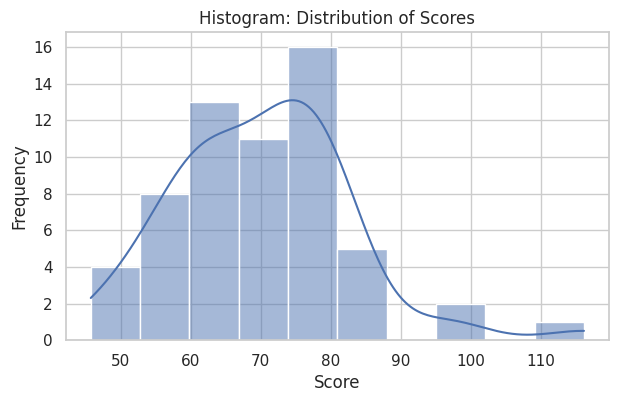

In [14]:
# 7.1 Histogram — distribution of a numerical variable
plt.figure()
sns.histplot(df_clean["score"], bins=10, kde=True, color="#4C72B0")
plt.title("Histogram: Distribution of Scores")
plt.xlabel("Score")
plt.ylabel("Frequency")
plt.show()


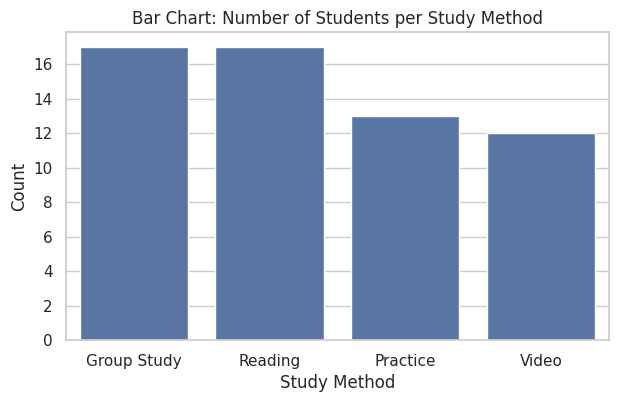

In [15]:
# 7.2 Bar Chart — comparing categories
plt.figure()
sns.countplot(data=df_clean, x="study_method", order=df_clean["study_method"].value_counts().index)
plt.title("Bar Chart: Number of Students per Study Method")
plt.xlabel("Study Method")
plt.ylabel("Count")
plt.show()


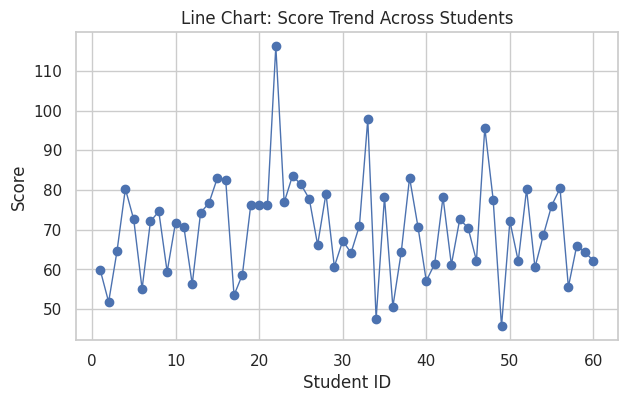

In [16]:
# 7.3 Line Chart — trend across an ordered index
plt.figure()
df_sorted = df_clean.sort_values("student_id")
plt.plot(df_sorted["student_id"], df_sorted["score"], marker="o", linewidth=1)
plt.title("Line Chart: Score Trend Across Students")
plt.xlabel("Student ID")
plt.ylabel("Score")
plt.show()


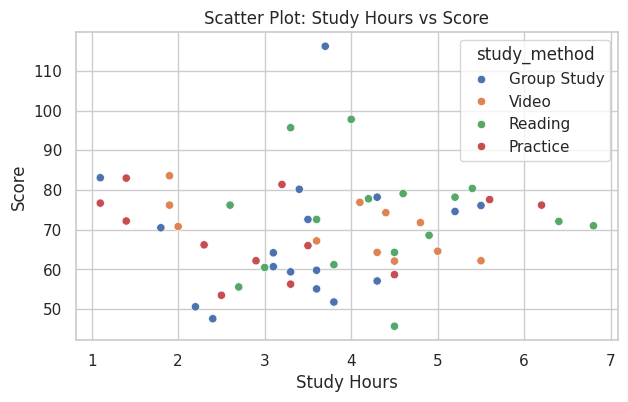

In [17]:
# 7.4 Scatter Plot — relationship between two numerical variables
plt.figure()
sns.scatterplot(data=df_clean, x="study_hours", y="score", hue="study_method")
plt.title("Scatter Plot: Study Hours vs Score")
plt.xlabel("Study Hours")
plt.ylabel("Score")
plt.show()


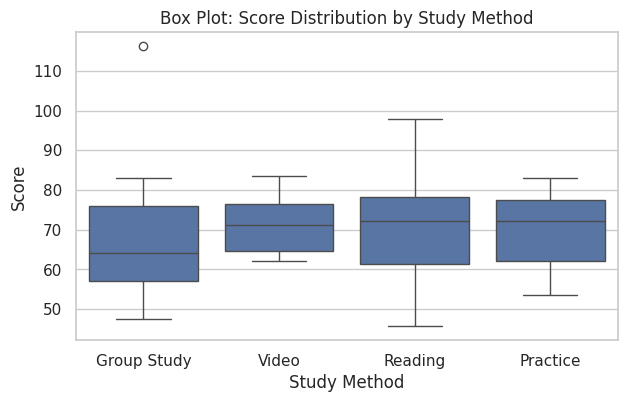

In [18]:
# 7.5 Box Plot — spotting spread and outliers
plt.figure()
sns.boxplot(data=df_clean, x="study_method", y="score")
plt.title("Box Plot: Score Distribution by Study Method")
plt.xlabel("Study Method")
plt.ylabel("Score")
plt.show()


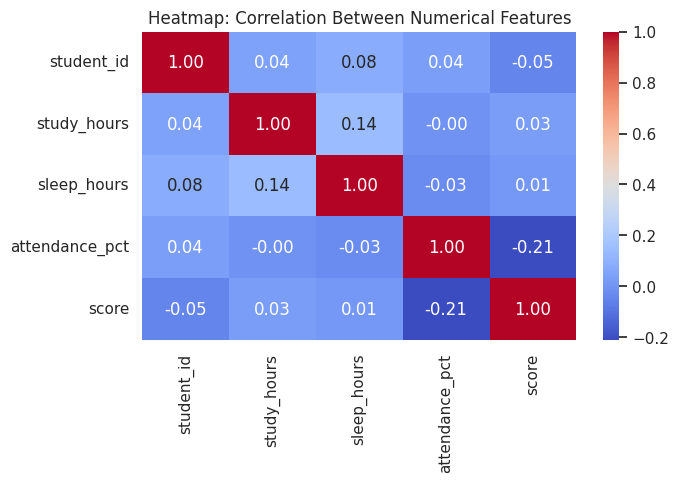

In [19]:
# 7.6 Heatmap — visualizing the correlation matrix
plt.figure()
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Heatmap: Correlation Between Numerical Features")
plt.show()


## 8. Feature Engineering

Well-designed features often contribute more to model performance than simply choosing a more
complex algorithm. Key techniques:

- **Feature Selection** — keeping only relevant columns
- **Feature Creation** — deriving new, more meaningful columns
- **Removing Irrelevant Features** — dropping columns with no predictive value
- **Encoding Categorical Variables** — converting text categories into numbers


In [20]:
# 8.1 Feature Creation — e.g. a 'study_efficiency' feature
df_features = df_clean.copy()
df_features["study_efficiency"] = df_features["score"] / df_features["study_hours"]

# 8.2 Feature Selection / Removing Irrelevant Features — student_id has no predictive value
df_features = df_features.drop(columns=["student_id"])

df_features.head()


   study_hours  sleep_hours  ...  score study_efficiency
0          3.6          6.5  ...   59.8        16.611111
1          3.8          6.8  ...   51.8        13.631579
2          5.0          5.9  ...   64.6        12.920000
3          NaN          5.8  ...   80.3              NaN
4          3.6          7.8  ...   72.6        20.166667

[5 rows x 6 columns]

In [21]:
# 8.3 Encoding Categorical Variables

# Label Encoding (ordinal-style encoding, simple integer codes)
label_encoder = LabelEncoder()
df_features["study_method_label"] = label_encoder.fit_transform(
    df_features["study_method"].astype(str)
)

# One-Hot Encoding (creates a separate binary column per category — usually preferred for ML)
one_hot = pd.get_dummies(df_features["study_method"], prefix="method")

df_encoded = pd.concat([df_features, one_hot], axis=1)
df_encoded.head()


   study_hours  sleep_hours  ...  method_Reading method_Video
0          3.6          6.5  ...           False        False
1          3.8          6.8  ...           False        False
2          5.0          5.9  ...           False         True
3          NaN          5.8  ...           False         True
4          3.6          7.8  ...            True        False

[5 rows x 11 columns]

## 9. Data Preprocessing

Proper preprocessing ensures that Machine Learning algorithms receive clean and consistent input data.

- **Handling Missing Values** — fill or remove them
- **Encoding Categorical Data** — covered above
- **Feature Scaling** — bringing numerical features to a comparable range
  - **Normalization** — rescales values to a fixed range, typically [0, 1]
  - **Standardization** — rescales values to have mean 0 and standard deviation 1


In [22]:
# 9.1 Handling Missing Values — impute with the median (robust to outliers)
df_processed = df_encoded.copy()

for col in ["study_hours", "sleep_hours"]:
    df_processed[col] = df_processed[col].fillna(df_processed[col].median())

print("Remaining missing values:")
print(df_processed.isnull().sum())


Remaining missing values:
study_hours           0
sleep_hours           0
attendance_pct        0
study_method          1
score                 0
study_efficiency      3
study_method_label    0
method_Group Study    0
method_Practice       0
method_Reading        0
method_Video          0
dtype: int64


In [23]:
# 9.2 Normalization — scales values into the range [0, 1]
minmax_scaler = MinMaxScaler()
normalized_cols = ["study_hours", "sleep_hours", "attendance_pct"]

df_normalized = df_processed.copy()
df_normalized[normalized_cols] = minmax_scaler.fit_transform(df_processed[normalized_cols])

df_normalized[normalized_cols].describe().loc[["min", "max"]]


     study_hours  sleep_hours  attendance_pct
min          0.0          0.0             0.0
max          1.0          1.0             1.0

In [24]:
# 9.3 Standardization — rescales values to mean = 0, std = 1
standard_scaler = StandardScaler()

df_standardized = df_processed.copy()
df_standardized[normalized_cols] = standard_scaler.fit_transform(df_processed[normalized_cols])

df_standardized[normalized_cols].describe().loc[["mean", "std"]]


       study_hours   sleep_hours  attendance_pct
mean  3.700743e-16 -5.107026e-16   -5.366078e-17
std   1.008439e+00  1.008439e+00    1.008439e+00

## 10. Data Splitting

Before training any model, datasets are divided into:

- **Training Set** — used to fit the model
- **Validation Set** — used to tune hyperparameters and check generalization during development
- **Test Set** — used only at the very end, to evaluate real-world performance

This prevents a model from simply *memorizing* the training data instead of *learning* patterns
that generalize to unseen data.


In [25]:
# Define features (X) and target (y)
feature_cols = ["study_hours", "sleep_hours", "attendance_pct"] + list(one_hot.columns)
X = df_processed[feature_cols]
y = df_processed["score"]

# First split: train (70%) vs temp (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42
)

# Second split: temp -> validation (15%) and test (15%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42
)

print("Training set:  ", X_train.shape)
print("Validation set:", X_val.shape)
print("Test set:      ", X_test.shape)


Training set:   (42, 7)
Validation set: (9, 7)
Test set:       (9, 7)


## 11. Full Data Preparation Pipeline — Recap

```
Raw Data
   → Data Cleaning        (missing values, duplicates, outliers)
   → EDA                  (summary stats, distributions, correlations)
   → Feature Engineering  (new features, selection, encoding)
   → Encoding & Scaling   (label/one-hot encoding, normalization/standardization)
   → Train/Val/Test Split
   → Machine Learning Model
```

This notebook walked through every stage of that pipeline on a small, realistic dataset — the same
workflow scales directly to real-world data used in Machine Learning and Deep Learning projects.


---
### 🔑 Key Takeaways

- Data Analysis is the foundation every AI/ML model is built on — garbage in, garbage out.
- EDA answers *"what does the data look like?"* before any model is trained.
- Visualizations reveal patterns and anomalies that raw numbers hide.
- Feature Engineering often improves performance more than switching algorithms.
- Preprocessing (cleaning, encoding, scaling) makes data consistent and model-ready.
- Splitting data properly lets us measure real generalization, not memorization.

**Next up (Module 4):** Machine Learning — Regression, Classification, Clustering, Model Evaluation, Scikit-learn.
